# Neural Networks with Regularization

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
# Setup

np.random.seed(42)
tf.random.set_seed(42)


# Dataset (5 features, 5 classes)

X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    n_classes=5,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Function to build model

def build_model(reg=None):
    model = keras.Sequential([
        layers.Dense(5, activation='relu', input_shape=(5,), kernel_regularizer=reg),
        layers.Dense(4, activation='relu', kernel_regularizer=reg),
        layers.Dense(3, activation='relu', kernel_regularizer=reg),
        layers.Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
# Models

model_base = build_model()  # No regularization
model_l1   = build_model(regularizers.l1(0.01))
model_l2   = build_model(regularizers.l2(0.01))
model_l1l2 = build_model(regularizers.l1_l2(l1=0.01, l2=0.01))



# Train Models

history_base = model_base.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)
history_l1   = model_l1.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)
history_l2   = model_l2.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)
history_l1l2 = model_l1l2.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=0)

In [6]:
# Print Results

def print_results(name, history):
    print(f"\n{name}")
    print("Train Acc:", round(history.history['accuracy'][-1], 4))
    print("Test Acc :", round(history.history['val_accuracy'][-1], 4))

print_results("No Regularization", history_base)
print_results("L1 Regularization", history_l1)
print_results("L2 Regularization", history_l2)
print_results("L1 + L2 Regularization", history_l1l2)


No Regularization
Train Acc: 0.7138
Test Acc : 0.715

L1 Regularization
Train Acc: 0.7887
Test Acc : 0.795

L2 Regularization
Train Acc: 0.7262
Test Acc : 0.725

L1 + L2 Regularization
Train Acc: 0.495
Test Acc : 0.425


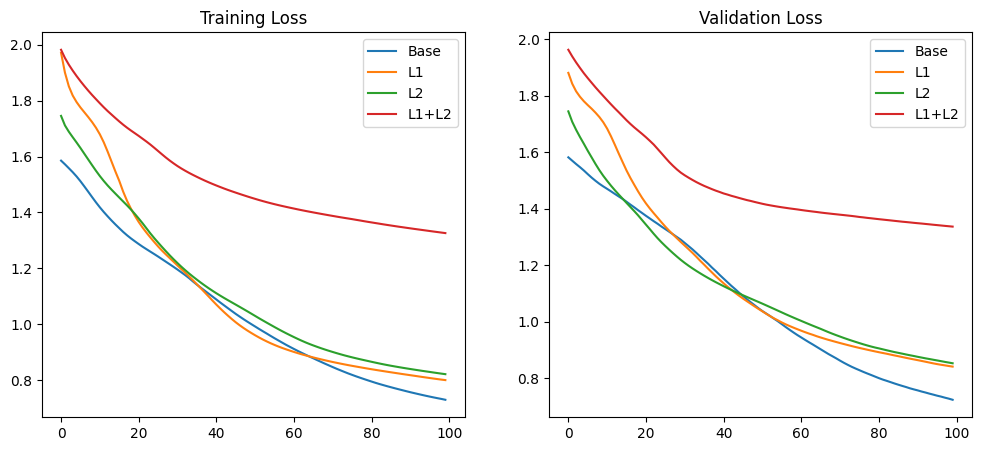

In [7]:
# Plot Loss

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_base.history['loss'], label='Base')
plt.plot(history_l1.history['loss'], label='L1')
plt.plot(history_l2.history['loss'], label='L2')
plt.plot(history_l1l2.history['loss'], label='L1+L2')
plt.title("Training Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_base.history['val_loss'], label='Base')
plt.plot(history_l1.history['val_loss'], label='L1')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_l1l2.history['val_loss'], label='L1+L2')
plt.title("Validation Loss")
plt.legend()

plt.show()

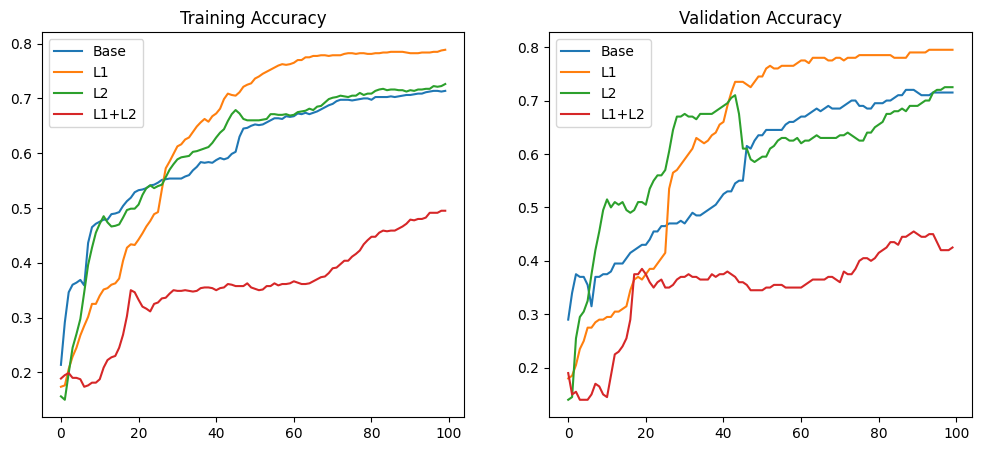

In [8]:
# Plot Accuracy

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_base.history['accuracy'], label='Base')
plt.plot(history_l1.history['accuracy'], label='L1')
plt.plot(history_l2.history['accuracy'], label='L2')
plt.plot(history_l1l2.history['accuracy'], label='L1+L2')
plt.title("Training Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_base.history['val_accuracy'], label='Base')
plt.plot(history_l1.history['val_accuracy'], label='L1')
plt.plot(history_l2.history['val_accuracy'], label='L2')
plt.plot(history_l1l2.history['val_accuracy'], label='L1+L2')
plt.title("Validation Accuracy")
plt.legend()

plt.show()